In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
def log_stretch(x, a=1000, mini=None, maxi=None):
    mini = x.min() if mini is None else mini
    maxi = x.max() if maxi is None else maxi
    normed = (x - mini) / (maxi - mini)
    normed[normed < 0] = 0
    normed[normed > 1] = 1
    return np.log10(a * normed + 1) / np.log10(a + 1)

In [3]:

rgb_files = [rf'data/M51/2024-05-08_23-46-16_R_-10.00_120.00s_0000.fits',
             rf'data/M51/2024-05-08_23-41-57_G_-10.00_120.00s_0000.fits',
             rf'data/M51/2024-05-08_23-53-06_B_-10.00_120.00s_0001.fits']

rgb_files = [rf"C:\Users\fauchere\Pictures\ASI178MM\20240508\M51\LIGHT\R\2024-05-09_00-53-17_R_-10.00_120.00s_0007.fits",
             rf"C:\Users\fauchere\Pictures\ASI178MM\20240508\M51\LIGHT\G\2024-05-09_01-07-07_G_-10.00_120.00s_0009.fits",
             rf"C:\Users\fauchere\Pictures\ASI178MM\20240508\M51\LIGHT\B\2024-05-09_01-09-17_B_-9.80_120.00s_0009.fits"]

dark_file = rf'data/ASI178MM_dark_iso100_t-10.000_120.00s_2025-08-23_sigma_clip.fits'
rgb_flat_files = [rf'data/flat_esprit100ED_iso00100_R_2025-08-23.fits',
                  rf'data/flat_esprit100ED_iso00100_G_2025-08-23.fits',
                  rf'data/flat_esprit100ED_iso00100_B_2025-08-23.fits']

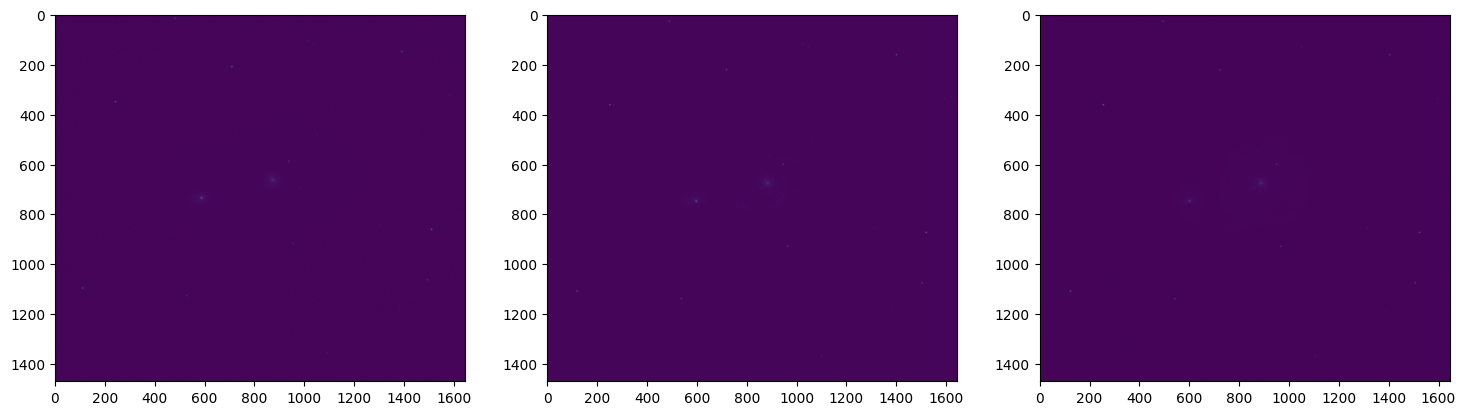

In [4]:

image = []
for file in rgb_files:
    image.append(fits.getdata(file))
image = np.array(image, dtype=float)
image = np.moveaxis(image, 0, -1)
#image[:, :, 0] = np.roll(image[:, :, 0], (10, 18), axis=(0, 1))

crop_y = slice(290,-320)
crop_x = slice(700, -750)

image = image[crop_y, crop_x, :]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
for ax, i in zip(axes, range(0, 3)):
    ax.imshow(image[:, :, i])

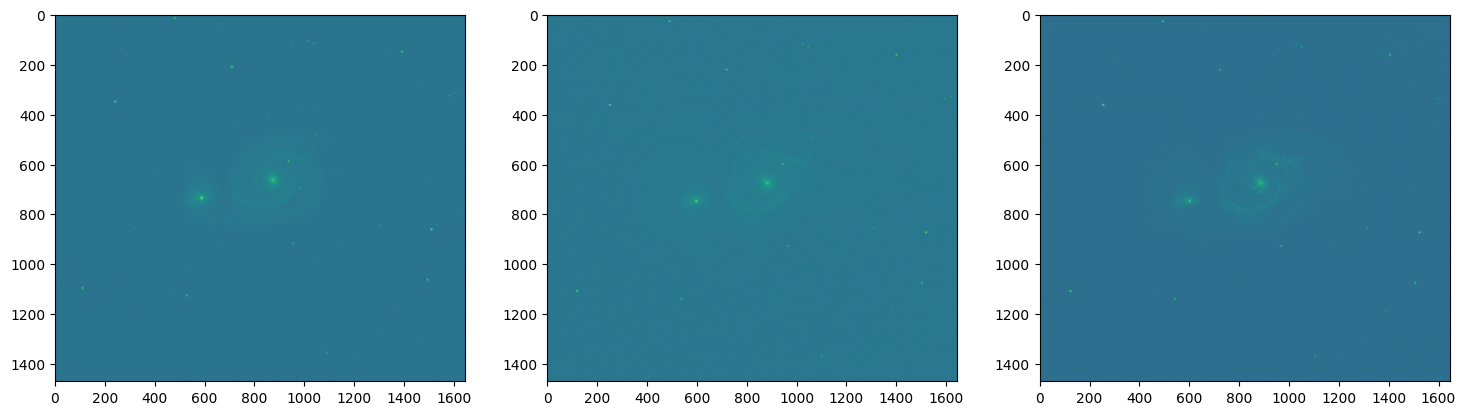

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
for ax, i in zip(axes, range(0, 3)):
    ax.imshow(log_stretch(image[:, :, i]))

Text(0, 0.5, 'Number of pixels')

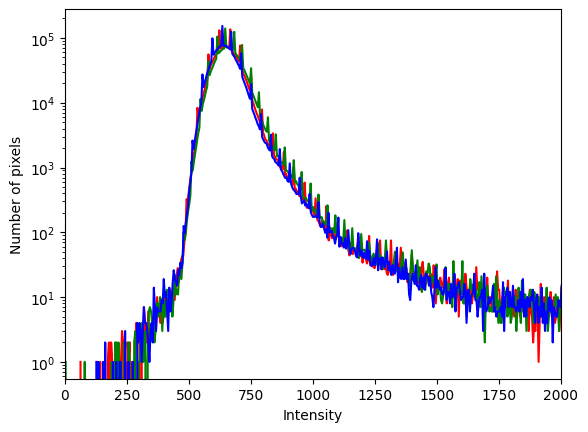

In [6]:
colors = ['red', 'green', 'blue']
fig, ax = plt.subplots(1, 1)
for i, color in zip(range(0, 3), colors):
    histo, bins = np.histogram(image[:, :, i], bins=10000)
    ax.plot(bins[:-1], histo, color=color)
ax.set_xlim(-100, 10000)
ax.set_xscale('linear')
ax.set_xlim(0, 2000)
ax.set_yscale('log')
ax.set_xlabel('Intensity')
ax.set_ylabel('Number of pixels')


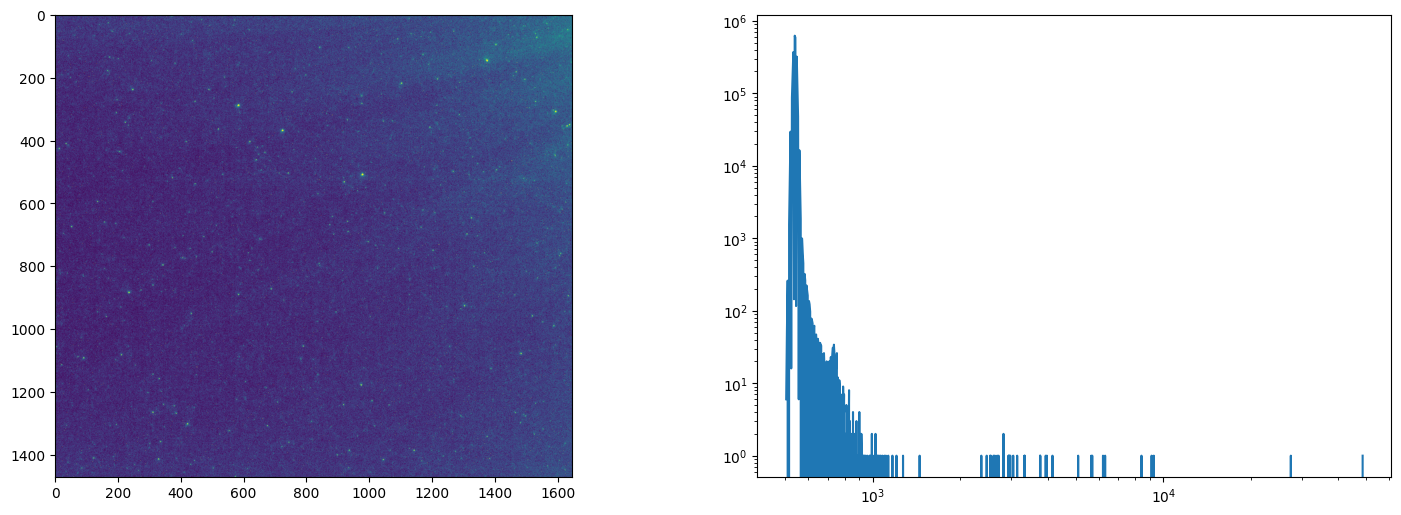

In [7]:
dark = fits.getdata(dark_file)
dark = dark[crop_y, crop_x]

histo, bins = np.histogram(dark, bins=16384)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(dark, vmin=530, vmax=600)
axes[1].plot(bins[:-1], histo)
axes[1].set_xscale('log')
axes[1].set_yscale('log')

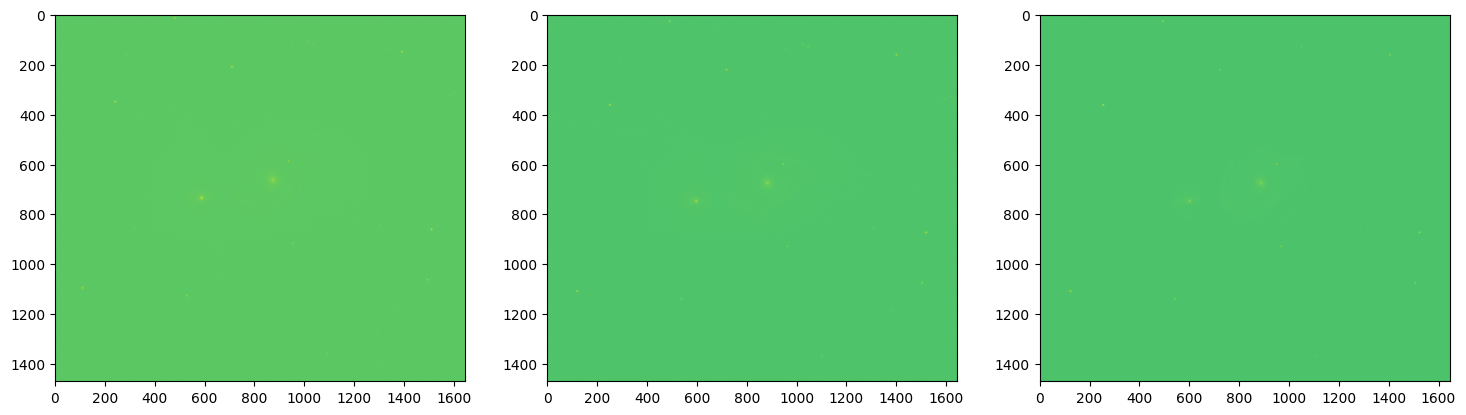

In [8]:
for i in range(0, 3):
    image[:, :, i] = image[:, :, i] - dark

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
for ax, i in zip(axes, range(0, 3)):
    ax.imshow(log_stretch(image[:, :, i]))

Text(0, 0.5, 'Number of pixels')

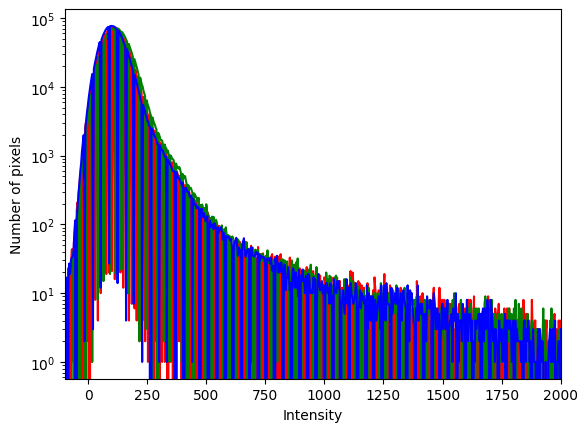

In [9]:
fig, ax = plt.subplots(1, 1)
for i, color in zip(range(0, 3), colors):
    histo, bins = np.histogram(image[:, :, i], bins=10000)
    ax.plot(bins[:-1], histo, color=color)
ax.set_xscale('linear')
ax.set_xlim(-100, 2000)
ax.set_yscale('log')
ax.set_xlabel('Intensity')
ax.set_ylabel('Number of pixels')

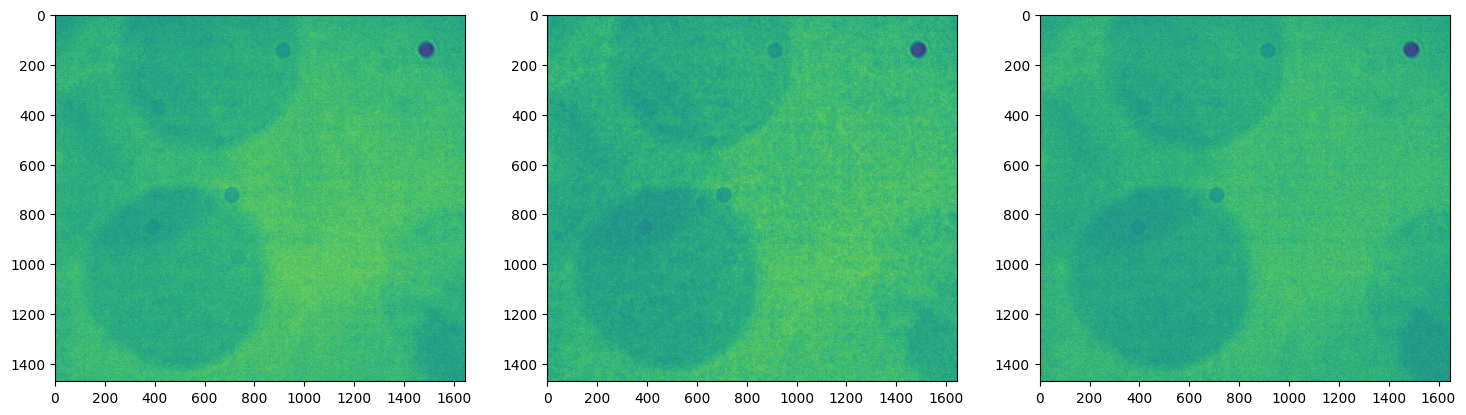

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, f, ax in zip(range(0, 3), rgb_flat_files, axes):
    flat = fits.getdata(f)[crop_y, crop_x]
    ax.imshow(flat)
    image[:, :, i] = image[:, :, i] / flat



In [11]:
for i in range(0, 3):
    image[:, :, i] = image[:, :, i] - np.median(image[:, :, i])

Text(0, 0.5, 'Number of pixels')

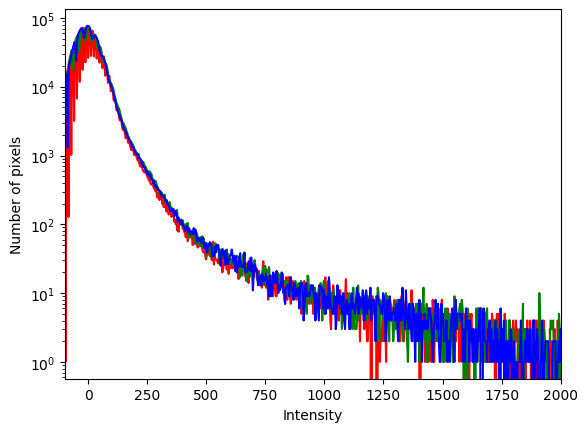

In [12]:
fig, ax = plt.subplots(1, 1)
for i, color in zip(range(0, 3), colors):
    histo, bins = np.histogram(image[:, :, i], bins=10000)
    ax.plot(bins[:-1], histo, color=color)
ax.set_xscale('linear')
ax.set_xlim(-100, 2000)
ax.set_yscale('log')
ax.set_xlabel('Intensity')
ax.set_ylabel('Number of pixels')

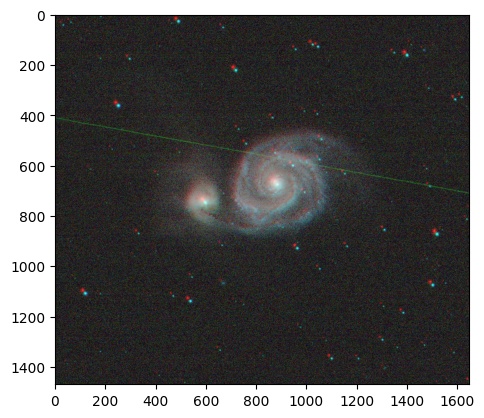

In [13]:
fig, ax = plt.subplots(1, 1)
ax.imshow(log_stretch(image, mini=-5, maxi=5000))
fig.savefig('image.png')